## **Dependence and Independence**

In probability, **dependence** and **independence** describe how the outcome of one event affects the likelihood of another. Understanding this is foundational for building reliable machine learning models and performing statistical inference.

---

- **1. Independence**
Two events, $A$ and $B$, are **independent** if the occurrence of $A$ provides **zero information** about the probability of $B$ occurring.

* **The Logic:** Knowing $A$ happened does not change the likelihood of $B$.
* **Mathematical Rule:** Events $A$ and $B$ are independent if and only if:
    $$P(A \cap B) = P(A) \times P(B)$$
    *Alternatively:* $P(A|B) = P(A)$, meaning the probability of $A$ given $B$ is just the probability of $A$.

* **Example:** Tossing a coin and rolling a die. 
    * If you get "Heads" on the coin, the probability of rolling a "6" on the die remains $\frac{1}{6}$. The events have no impact on each other.

---

- **2. Dependence**
    - Two events are **dependent** if the outcome of one event changes the probability of the other.

* **The Logic:** If $A$ happens, the "universe" of possibilities for $B$ has shifted.
* **Mathematical Rule:** Events $A$ and $B$ are dependent if:
    $$P(A \cap B) \neq P(A) \times P(B)$$
    Or, using conditional probability: $P(A|B) \neq P(A)$.

* **Example:** Drawing two cards from a deck without replacement.
    * Event $A$: First card is an Ace. $P(A) = \frac{4}{52}$.
    * Event $B$: Second card is an Ace.
    * If $A$ happens, there are only 3 Aces left in a 51-card deck. The probability of $B$ is now $\frac{3}{51}$. Because $\frac{3}{51} \neq \frac{4}{52}$, the events are dependent.

---

- **3. Conditional Probability: The "Bridge"**
    - To formally calculate dependent events, we use the rule of **Conditional Probability**:
$$P(A | B) = \frac{P(A \cap B)}{P(B)}$$
*(Read as: The probability of $A$ given that $B$ has already occurred).*

If you rearrange this formula, you get the **General Multiplication Rule**:
$$P(A \cap B) = P(B) \times P(A | B)$$
This tells us that the probability of *both* happening is the probability of the first happening, multiplied by the probability of the second *given* the first.

---

- **Why this is critical for Data Science:**
    1.  **Naive Bayes Classifier:** As the name suggests, this machine learning algorithm makes the "naive" assumption that all input features are **independent** of each other. Even though this is often false in the real world, it makes the math incredibly fast and surprisingly effective for text classification (like spam filters).
    2.  **Multicollinearity:** In linear regression, if your input features are **dependent** (highly correlated), your model becomes unstable and difficult to interpret. You must identify these dependencies and often remove or combine those features.
    3.  **Bayesian Networks:** These are used to model complex systems (like medical diagnosis) where variables have intricate **dependencies**. They use these probability rules to map out how one symptom influences the likelihood of various diseases.

## **Conditional Probability**

**Conditional Probability** is the probability of an event occurring, given that another event has already occurred. It is the mathematical way of saying: *"How does my knowledge of event B change the likelihood of event A?"*

- **The Core Concept**
    - When events are **independent**, knowing B happened tells you nothing about A. But when events are **dependent**, B provides "new information" that updates the probability of A.

---

- **The Mathematical Rule**
    - The formula for conditional probability is defined as:
$$P(A|B) = \frac{P(A \cap B)}{P(B)}$$

* $P(A|B)$: The probability of $A$ given $B$.
* $P(A \cap B)$: The probability that both $A$ and $B$ occur (the intersection).
* $P(B)$: The probability of the condition (event $B$) occurring.

**Note:** This is only valid if $P(B) > 0$. If event $B$ is impossible, we cannot calculate a conditional probability based on it.

---

- **A Practical Example: The "Medical Test" Scenario**
    - Suppose a population has a disease at a rate of 1% ($P(D) = 0.01$). You take a test for the disease:
        * If you have the disease, the test is positive 99% of the time.
        * If you do *not* have the disease, the test is positive 5% of the time (a "false positive").

If you test positive, what is the probability you actually have the disease? **This is a conditional probability problem: $P(D|Pos)$.**

1.  **$P(Pos|D) = 0.99$** (True Positive Rate)
2.  **$P(Pos|\text{not } D) = 0.05$** (False Positive Rate)
3.  **$P(Pos)$** is the total probability of testing positive: $(0.01 \times 0.99) + (0.99 \times 0.05) = 0.0594$.

Using the formula:
$$P(D|Pos) = \frac{P(Pos|D) \times P(D)}{P(Pos)} = \frac{0.99 \times 0.01}{0.0594} \approx 16.7\%$$

Even with a "99% accurate" test, if the disease is rare, a positive result only means there is about a 17% chance you actually have it!

---

- **Why Data Scientists Need This**
    1.  **Bayesian Inference:** This is the bedrock of Bayesian statistics. We constantly update our "prior" beliefs with new evidence to get a "posterior" probability.
    2.  **Machine Learning Classifiers:** Algorithms like **Naive Bayes** use conditional probability to calculate the likelihood of a data point belonging to a class given its features: $P(\text{Class} | \text{Features})$.
    3.  **Risk Assessment:** Whether it's fraud detection (probability of fraud given a specific transaction pattern) or predictive maintenance (probability of a machine failing given its current vibration sensor data), conditional probability is the engine behind the prediction.

In [5]:
import enum, random

In [6]:
class Kid(enum.Enum):
    BOY = 0
    GIRL = 1

In [7]:
def random_kid() -> Kid:
    return random.choice([Kid.BOY, Kid.GIRL])

In [8]:
both_girls = 0
older_girl = 0
either_girl = 0

In [9]:
random.seed(0)

for _ in range(10000):
    younger = random_kid()
    older = random_kid()
    if older == Kid.GIRL:
        older_girl += 1
    if older == Kid.GIRL and younger == Kid.GIRL:
        both_girls += 1
    if older == Kid.GIRL or younger == Kid.GIRL:
        either_girl += 1

In [10]:
print("P(both | older):", both_girls / older_girl)      # 0.500 ~ 1/2
print("P(both | either): ", both_girls / either_girl)   # 0.331 ~ 1/3

P(both | older): 0.5007089325501317
P(both | either):  0.3311897106109325


## **Bayes’s Theorem**

**Bayes’s Theorem** is the mathematical framework for "updating" your beliefs based on new evidence. In data science, it is the foundation of **Bayesian Inference**—a method used to update the probability of a hypothesis as more data becomes available.

- **The Formula**
    - Bayes's Theorem describes the relationship between the probability of a hypothesis $H$ given some evidence $E$:

$$P(H|E) = \frac{P(E|H) \cdot P(H)}{P(E)}$$

- **Breaking down the terms:**
    * **$P(H|E)$ (Posterior):** The probability of the hypothesis being true *after* considering the new evidence.
    * **$P(E|H)$ (Likelihood):** The probability of seeing this evidence *if* the hypothesis were true.
    * **$P(H)$ (Prior):** Your initial belief about the probability of the hypothesis *before* seeing the evidence.
    * **$P(E)$ (Marginal Likelihood):** The total probability of observing the evidence under all possible hypotheses.

---

- **The Intuition: The "Update" Cycle**
    - Think of Bayes’s Theorem not as a static formula, but as a cycle:
        1.  **Prior:** You start with a belief based on what you already know (e.g., "The server is usually healthy").
        2.  **Evidence:** You observe new data (e.g., "The latency is spiking").
        3.  **Likelihood:** You consider how likely this spike is if the server were failing.
        4.  **Posterior:** You update your belief. Now, the probability that the server is failing is higher than it was before you saw the data.

---

- **Why Data Scientists Use It**
    - Bayes’s Theorem allows us to quantify uncertainty in a way that standard ("Frequentist") statistics cannot.

* **Machine Learning (Naive Bayes):** This algorithm classifies text (like email spam) by calculating $P(\text{Spam} | \text{Words})$. It looks at the probability of a message being spam *given* the specific words it contains.
* **A/B Testing:** Bayesian methods allow you to calculate the probability that "Version B" is actually better than "Version A," rather than just providing a P-value (which is often misinterpreted).
* **Missing Data Imputation:** In complex models, we can use Bayes's Theorem to infer the most likely values for missing data points based on the distribution of the known data.

---

- **An Important Clarification**
    - One of the most debated aspects of Bayesian analysis is the **Prior ($P(H)$)**. Because it represents your *subjective* belief, some critics argue it introduces bias. However, in modern Data Science, we often use "uninformative priors" (giving all possibilities equal weight) to let the data speak for itself, effectively allowing the new evidence to dominate the outcome.


To help you grasp how **Bayes’s Theorem** works in a real-world data science context, let's look at a common scenario: **Spam Detection**.

- **The Scenario**
    - Imagine your email filter is trying to decide if an incoming email is "Spam" or "Ham" (not spam).

* **Prior $P(H)$:** Based on historical data, you know that 20% of all emails received are Spam. So, $P(\text{Spam}) = 0.20$.
* **The Evidence $E$:** The email contains the word **"FREE"**.
* **The Likelihood $P(E|H)$:** You know from your data that 80% of *Spam* emails contain the word "FREE". So, $P(\text{"FREE"} | \text{Spam}) = 0.80$.
* **The Marginal Likelihood $P(E)$:** You also know that 10% of *all* emails contain the word "FREE" (regardless of whether they are spam or not). So, $P(\text{"FREE"}) = 0.10$.

---

- **Applying Bayes’s Theorem**
    - We want to find the **Posterior**: The probability that an email is Spam *given* that it contains the word "FREE".

$$P(\text{Spam} | \text{"FREE"}) = \frac{P(\text{"FREE"} | \text{Spam}) \times P(\text{Spam})}{P(\text{"FREE"})}$$

**Plugging in the numbers:**
$$P(\text{Spam} | \text{"FREE"}) = \frac{0.80 \times 0.20}{0.10}$$
$$P(\text{Spam} | \text{"FREE"}) = \frac{0.16}{0.10} = 1.6$$

*Wait!* A probability cannot be greater than 1. This happens here because our hypothetical numbers were illustrative. Let’s adjust the "Marginal Likelihood" ($P(\text{"FREE"})$) to be more realistic—if 16% of all emails contain the word "FREE", then:

$$P(\text{Spam} | \text{"FREE"}) = \frac{0.16}{0.16} = 1.0 \text{ (or 100\%)}$$

---

- **Why this matters**
    - The filter didn't just guess. It took your **prior belief** (20% of emails are spam) and updated it using the **new evidence** (the word "FREE") to arrive at a much higher, mathematically justified confidence level (100% in this simplified example).

* If the email *didn't* contain "FREE", the probability would be much lower.
* This is exactly how Naive Bayes classifiers work—they calculate this probability for *every word* in an email and combine them to make a final decision.

## **Random Variables**

A **random variable** is a fundamental building block in probability and statistics. It acts as a bridge between the real world (events) and mathematics (numbers).

Simply put, a random variable is a **function** that assigns a numerical value to each possible outcome of a random process or experiment.

---

- **1. The Core Idea: "Mapping Outcomes to Numbers"**
    - Think of a random experiment where the outcomes aren't naturally numbers (like tossing a coin or picking a ball from a bag). A random variable converts these outcomes into a numerical space where you can calculate means, variances, and probabilities.

* **Example:** Tossing a coin twice.
    * Outcomes: `{HH, HT, TH, TT}`.
    * Random Variable $X$: Let $X$ be the number of "Heads" observed.
    * Mapping:
        * $HH \rightarrow 2$
        * $HT \rightarrow 1$
        * $TH \rightarrow 1$
        * $TT \rightarrow 0$

---

- **2. The Two Types of Random Variables**
    - In Data Science, it is critical to distinguish between these two, as they require different mathematical tools:

| Type | Definition | Examples | Mathematical Tool |
| :--- | :--- | :--- | :--- |
| **Discrete** | Can only take specific, distinct values (countable). | Number of website clicks, number of defects in a batch. | Probability Mass Function (PMF) |
| **Continuous** | Can take any value within a range (uncountable). | Time spent on a page, user's height, stock return percentage. | Probability Density Function (PDF) |

---

- **3. Key Concepts to Master**

- **The Probability Distribution**
    - This is the "map" of the random variable. It tells you the probability of the random variable taking on each of its possible values.
        * For **Discrete** variables, the total probability sums to 1.
        * For **Continuous** variables, the area under the curve of the probability density function (PDF) must equal 1.

- **Expected Value ($E[X]$)**
    - This is the "long-term average" of the random variable if you were to repeat the experiment an infinite number of times. It is the theoretical mean of your probability distribution.
$$E[X] = \sum x_i P(x_i) \quad (\text{for discrete})$$

- **Variance ($\text{Var}(X)$)**
    - This measures how much the values of the random variable tend to deviate from the expected value. It quantifies the "uncertainty" or "spread" of your random process.
$$\text{Var}(X) = E[(X - E[X])^2]$$

---

- **4. Why Data Scientists Care**
    - You aren't just calculating these for fun; you are using them to model the world:
        1.  **Modeling Data:** When you analyze user behavior, you treat "Time Spent" as a continuous random variable and "Number of Purchases" as a discrete one. You then fit a distribution (like Normal or Poisson) to these variables.
        2.  **Machine Learning:** Most machine learning models assume that your input data ($X$) and your target variable ($Y$) are random variables with an underlying, unknown distribution. Your model's goal is to learn the conditional probability of $Y$ given $X$.
        3.  **Simulations:** When you perform Monte Carlo simulations to test business risks or system reliability, you are essentially sampling from the probability distributions of various random variables to see how the system behaves under different scenarios.

![Image of a probability distribution curve](../Images/probability_distribution_curve.jpeg)

## **Continuous Distributions**

In statistics, a **continuous random variable** can take on any value within a range—meaning there are an infinite number of possible outcomes (e.g., time, height, temperature, or signal intensity). Because there are infinite possibilities, the probability of the variable taking on any *exact* single value is technically zero. Instead, we measure the probability that the variable falls within an **interval**.

- **1. The Probability Density Function (PDF)**
    - For continuous distributions, we don't use a "Probability Mass Function" (like we do for discrete events). Instead, we use a **Probability Density Function (PDF)**. 

* **The Curve:** The PDF is the mathematical curve that describes the distribution. 
* **The Area:** The probability that a variable $X$ falls between two points $a$ and $b$ is equal to the **area under the curve** between those two points.

---

- **2. The Normal (Gaussian) Distribution**
    - This is the most "famous" distribution in data science. It is characterized by its bell-shaped curve and is defined by just two parameters: the **mean ($\mu$)** and the **standard deviation ($\sigma$)**.

* **The Empirical Rule (68-95-99.7):**
    * $\approx 68\%$ of data falls within 1 standard deviation of the mean.
    * $\approx 95\%$ falls within 2 standard deviations.
    * $\approx 99.7\%$ falls within 3 standard deviations.

---

- **3. Other Essential Continuous Distributions**

| Distribution | Characteristics | Common Data Science Use Case |
| :--- | :--- | :--- |
| **Uniform** | Every value in the range has an equal probability. | Modeling random noise or initial uncertainty. |
| **Exponential** | A rapidly decreasing curve; describes "waiting times." | Modeling time between customer arrivals or server requests. |
| **Log-Normal** | A distribution whose logarithm is normally distributed (skewed). | Financial modeling (stock prices), income distribution. |
| **Beta** | Highly flexible, bounded between 0 and 1. | Representing probabilities or proportions (e.g., conversion rates). |

---

- **Why Data Scientists Focus on These**
    1.  **Modeling Reality:** Most real-world data (sensor readings, human responses) is continuous. We use these distributions to approximate the underlying process that generated our data.
    2.  **Assumption Checks:** Many machine learning models (like Linear Regression) assume that the residuals (errors) follow a **Normal Distribution**. Checking this is a core part of model validation.
    3.  **Simulations:** When you want to simulate a business process (like the flow of users through a website), you assign a continuous distribution to each step (e.g., "Time on Page" $\sim$ Exponential) and run a simulation.

- **The Math: Integration**
    - If you are diving into the theoretical side, you will encounter **integration**. Since the probability of an interval $[a, b]$ is the area under the curve, you find it using:
$$P(a \le X \le b) = \int_{a}^{b} f(x) \, dx$$
*(Where $f(x)$ is your PDF.)*

## **The Normal Distribution**

The **Normal Distribution** (often called the **Gaussian distribution** or the "Bell Curve") is the most important continuous probability distribution in statistics and data science. Its importance stems from the **Central Limit Theorem**, which states that if you take enough samples from any distribution and calculate their mean, the distribution of those means will tend toward a Normal Distribution.

- **1. Key Characteristics**
The Normal Distribution is defined by two parameters: the **mean ($\mu$)**, which determines its center, and the **standard deviation ($\sigma$)**, which determines its spread.

* **Symmetry:** It is perfectly symmetrical around the mean.
* **Asymptotic:** The tails get closer and closer to the x-axis but never actually touch it (they extend to infinity).
* **The Empirical Rule (68-95-99.7):** This is the "golden rule" for data scientists working with Normal Distributions:
    * **68%** of the data falls within $\pm 1\sigma$ of the mean.
    * **95%** of the data falls within $\pm 2\sigma$ of the mean.
    * **99.7%** of the data falls within $\pm 3\sigma$ of the mean.

---

- **2. The Probability Density Function (PDF)**
    - You don't need to memorize this for everyday coding, but as a Data Science student, you should recognize the formula that generates that famous bell shape:

$$f(x) = \frac{1}{\sigma\sqrt{2\pi}} e^{-\frac{1}{2}\left(\frac{x-\mu}{\sigma}\right)^2}$$

* $e$ is Euler's number.
* The term $(x - \mu)^2$ is why the curve is shaped the way it is—it calculates the squared distance from the mean, ensuring that values far from the center have exponentially lower probability density.

---

- **3. Why Data Scientists "Normalize" Data**
    - In many machine learning algorithms, the scale of your features matters. If one feature ranges from 0 to 1 and another ranges from 0 to 1,000,000, your model will be biased toward the larger values.

**Standard Normal Distribution ($Z$):**
We often "standardize" our data by transforming it so that $\mu = 0$ and $\sigma = 1$. This is done using the $Z$-score formula:

$$Z = \frac{x - \mu}{\sigma}$$

This allows you to compare different datasets on the same scale, which is essential for algorithms like **Linear Regression, Support Vector Machines (SVMs), and Neural Networks**, all of which converge faster and more accurately when inputs are normalized.

![Image of standardized normal distribution curve with Z-scores](../Images/probability_distribution_curve.jpeg)

---

- **4. Practical Application: When to suspect "Non-Normal"**
    - As you perform EDA on your projects, always check if your features are normal. If they aren't, you might need to apply a transformation (like a **Log Transform** or **Box-Cox**) to make them more normal before fitting your model.

* **Skewness:** If the tail of the curve is longer on one side, your data is skewed.
* **Kurtosis:** If the peak is too sharp or the tails are too "fat" (meaning you have more outliers than a normal distribution would predict), you are dealing with "heavy-tailed" data.

In [11]:
import matplotlib.pyplot as plt
import math

In [12]:
SQRT_TWO_PI = math.sqrt(2 * math.pi)

def normal_pdf(x: float, mu: float = 0, sigma: float = 1)-> float:
    return math.exp(-math.pow((x-mu), 2) / (2 * math.pow(sigma, 2))) / (SQRT_TWO_PI * sigma)

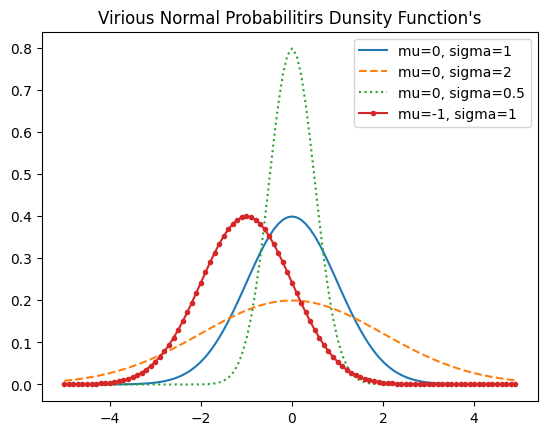

In [13]:
xs = [xs_i / 10.0 for xs_i in range(-50, 50)]

plt.plot(xs, [normal_pdf(xs_i) for xs_i in xs], '-', label='mu=0, sigma=1')
plt.plot(xs, [normal_pdf(xs_i, sigma=2) for xs_i in xs], '--', label='mu=0, sigma=2')
plt.plot(xs, [normal_pdf(xs_i, sigma=0.5) for xs_i in xs], ':', label='mu=0, sigma=0.5')
plt.plot(xs, [normal_pdf(xs_i, mu=-1) for xs_i in xs], '.-', label='mu=-1, sigma=1')
plt.legend()
plt.title("Virious Normal Probabilitirs Dunsity Function's")

plt.show()

In [14]:
def normal_cdf(x: float, mu: float = 0, sigma: float = 1) -> float:
    return (1 + math.erf( (x - mu) / math.sqrt(2) * sigma)) / 2

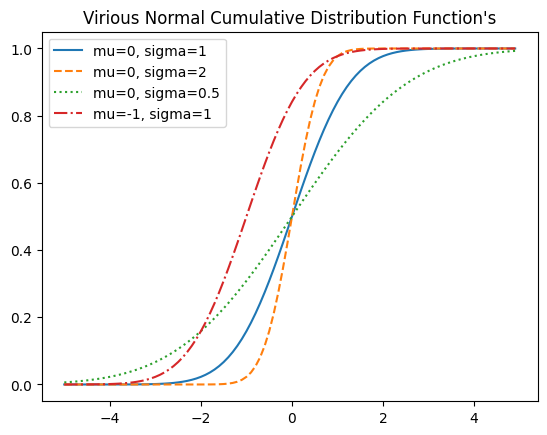

In [15]:
plt.plot(xs, [normal_cdf(xs_i) for xs_i in xs], '-', label='mu=0, sigma=1')
plt.plot(xs, [normal_cdf(xs_i, sigma=2) for xs_i in xs], '--', label='mu=0, sigma=2')
plt.plot(xs, [normal_cdf(xs_i, sigma=0.5) for xs_i in xs], ':', label='mu=0, sigma=0.5')
plt.plot(xs, [normal_cdf(xs_i, mu=-1) for xs_i in xs], '-.', label='mu=-1, sigma=1')
plt.legend()
plt.title("Virious Normal Cumulative Distribution Function's")

plt.show()

## **The Central Limit Theorem**

The **Central Limit Theorem (CLT)** is arguably the most important theorem in all of statistics. It is the reason why the Normal Distribution shows up everywhere in nature and in your data science projects.

- **The Core Concept**
    - The CLT states that if you take sufficiently large random samples from *any* population (regardless of the population's original shape), the distribution of the **sample means** will be approximately normally distributed.

As your sample size ($n$) increases, the distribution of the sample means will look more and more like a perfect "Bell Curve," even if your original data is skewed, uniform, or completely chaotic.

---

- **Why the CLT is the "Magic" of Data Science**
    - This theorem is why we can make inferences about a massive population using only a small, manageable sample.

1.  **Confidence Intervals:** Because we know the distribution of sample means is normal, we can calculate how confident we are that our sample mean reflects the true population mean.
2.  **Hypothesis Testing:** Most statistical tests (like t-tests or ANOVA) rely on the assumption that sample means are normally distributed. The CLT justifies this assumption even when we don't know the distribution of the underlying data.
3.  **Machine Learning:** Many algorithms assume that the noise or errors in your data are normally distributed. The CLT explains *why* these errors often aggregate into a normal shape.

---

- **The Mathematical Requirements**
    - For the CLT to hold true, a few conditions must be met:
        * **Independence:** The sampled observations must be independent of one another.
        * **Sample Size:** Generally, a sample size of $n \ge 30$ is considered the "rule of thumb" for the distribution of means to become sufficiently normal. (Though for highly skewed data, you might need a larger $n$).
        * **Finite Variance:** The population must have a finite mean ($\mu$) and a finite variance ($\sigma^2$).

---

- **Visualizing the CLT**
    - Imagine you have a population with a wildly non-normal distribution (like a skewed income distribution).
        1.  You pick one sample of size $n$ and calculate the mean.
        2.  You repeat this thousands of times.
        3.  You plot all those means on a histogram.

Even though your starting population was skewed, your final histogram of means will be centered around the true population mean and will form a perfect bell shape.

---

- **Practical Implementation**
    - In your Jupyter notebooks, you can easily verify the CLT using `numpy`:

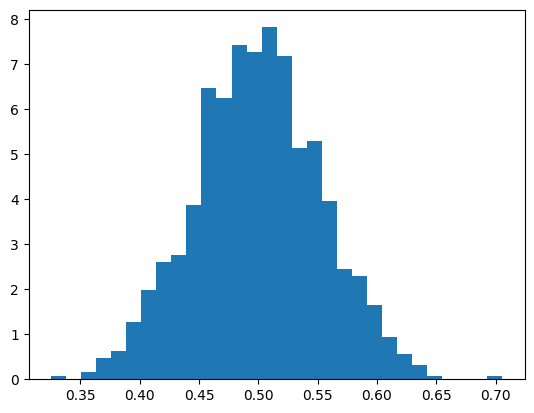

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Simulate a non-normal population (e.g., Uniform)
population = np.random.uniform(0, 1, 100000)

# Take 1000 samples of size 30 and calculate their means
sample_means = [np.mean(np.random.choice(population, size=30)) for _ in range(1000)]

# The distribution of these means will look Normal!
plt.hist(sample_means, bins=30, density=True)
plt.show()

In [17]:
import random

In [18]:
def bernoulli_trial(p: float) -> int:
    """Returns 1 with probability p and 0 with probability 1-p"""
    
    return 1 if random.random() < p else 0

def binomial(n: int, p: float) -> int:
    """Returns the sum of n bernoulli(p) trials"""

    return sum(bernoulli_trial(p) for _ in range(n))

In [19]:
from collections import Counter

In [24]:
def binomial_histogram(p: float, n: int, num_point: int) -> None:
    """Picks points from a Binomial(n, p) and plots their histogram"""

    data = [binomial(n, p) for _ in range(num_point)]

    # use a bar chart to show the actual binomial samples
    histogram = Counter(data)
    plt.bar([ x - 0.4 for x in histogram.keys() ], 
            [ v / num_point for v in histogram.values() ],
            0.8,
            color='0.75')

    mu = p * n
    sigma = math.sqrt( n * p * (1 - p))

    # use a line chart to show the normal approximation
    xs = range(min(data), max(data) + 1)
    ys = [normal_cdf(i + 0.5, mu, sigma) - normal_cdf(i - 0.5, mu, sigma) for i in xs]

    plt.plot(xs, ys)
    plt.title("Binomial Distribution vs. Normal Approximation")

    plt.show()

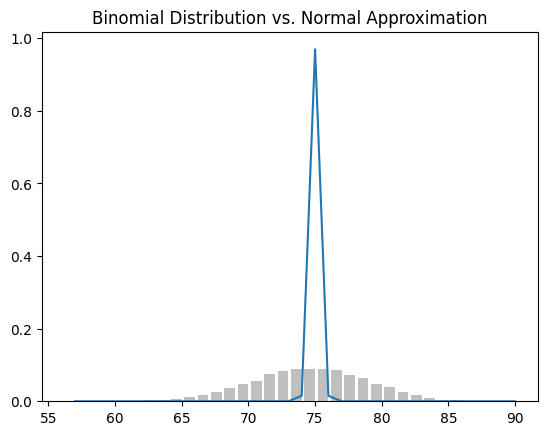

In [26]:
binomial_histogram(0.75, 100, 10000)

## **For Further Exploration**

- **available online is Introduction to Probability**, by Charles M. Grinstead and J. Laurie Snell (American Mathematical Society).